In [5]:
library(lme4)
library(emmeans)
library(ggplot2)
library(dplyr)

Warning message:
"package 'ggplot2' was built under R version 4.4.3"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




In [ ]:
#### GENERALIZATION ANALYSIS

[1] "Working directory: C:/Users/jacob/water_current_MA/data/spatial_generalization"


Contrasts set to contr.sum for the following variables: target_x_label, phase, strict_id



Mixed Model Anova Table (Type 3 tests, S-method)

Model: PCA_extent_error_cm_mean_bc ~ target_x_label * phase + (1 | strict_id)
Data: df_subset
                Effect       df          F p.value
1       target_x_label 1, 65.59 117.01 ***   <.001
2                phase 1, 65.59  13.54 ***   <.001
3 target_x_label:phase 1, 65.59     3.29 +    .074
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '+' 0.1 ' ' 1


NOTE: Results may be misleading due to involvement in interactions



 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2      -16 4.34 66.7    -24.6     -7.3  -3.679  0.0005

Results are averaged over the levels of: target_x_label 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 
target_x_label = L60:
 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2   -23.82 6.10 67.0    -36.0   -11.64  -3.904  0.0002

target_x_label = R60:
 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -8.09 6.17 66.5    -20.4     4.22  -1.312  0.1940

Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 


Warning message:
"package 'ggplot2' was built under R version 4.4.3"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




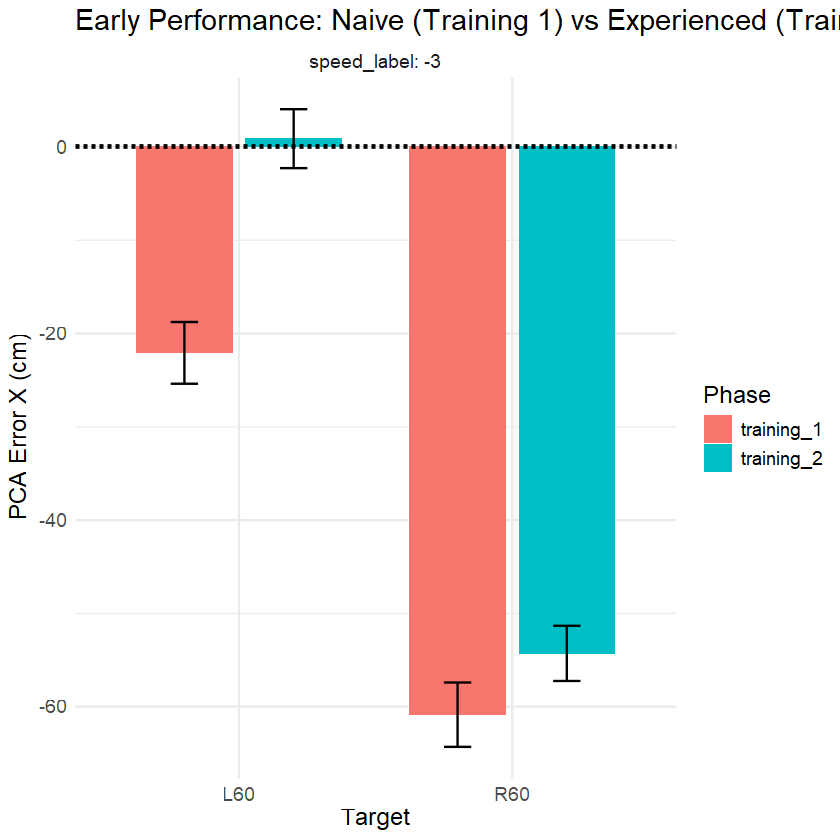

In [15]:
library(afex)
library(emmeans) 

setwd("C:/Users/jacob/water_current_MA/data/spatial_generalization")
dir <- getwd()
print(paste("Working directory:", dir))

df_single_3 <- read.csv("early_late_phase_PCA_error_novel_TU_3.0M_spatial_generalization_novel_TD_3.0M_spatial_generalization_speed_neg3_0.csv")

# Ensure factors
df_single_3$ppid_full <- factor(df_single_3$ppid_full)
df_single_3$speed_label <- factor(df_single_3$speed_label)

# leave out late trials
df_early <- df_single_3[df_single_3$trial_set == "early", ]
speeds_list <- unique(df_early$speed_label)

for (s in speeds_list) {
  
  df_subset <- df_early[df_early$speed_label == s,]
  df_subset <- droplevels(df_subset) 

  df_subset$strict_id <- paste(df_subset$phase, df_subset$ppid_full, sep="_")
    
  mm_gen <- afex::mixed(PCA_extent_error_cm_mean_bc ~ target_x_label * phase + (1|strict_id),
                        data = df_subset, method = "S")
  
  print(afex::nice(mm_gen))
  
  emm_mm_gen <- emmeans(mm_gen, ~ phase)
  emm_by_target <- emmeans(mm_gen, ~ phase | target_x_label)
  
  print(pairs(emm_mm_gen, infer = TRUE))
  print(pairs(emm_by_target, adjust = "holm", infer = TRUE))
}


library(ggplot2)
library(dplyr)

# Calculate means and standard errors for plotting
plot_data <- df_early %>%
  group_by(speed_label, phase, target_x_label) %>%
  summarise(
    mean_error = mean(PCA_extent_error_cm_mean_bc, na.rm = TRUE),
    se_error = sd(PCA_extent_error_cm_mean_bc, na.rm = TRUE) / sqrt(n()),
    .groups = "drop"
  )

# Create the plot
ggplot(plot_data, aes(x = target_x_label, y = mean_error, fill = phase)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.8), width = 0.7) +
  geom_errorbar(aes(ymin = mean_error - se_error, ymax = mean_error + se_error),
                position = position_dodge(width = 0.8), width = 0.2) +
  facet_wrap(~ speed_label, labeller = label_both) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "black", linewidth = 1) + # 0 line
  theme_minimal() +
  labs(
    title = "Early Performance: Naive (Training 1) vs Experienced (Training 2)",
    x = "Target",
    y = "PCA Error X (cm)",
    fill = "Phase"
  ) +
  theme(text = element_text(size = 14))

In [ ]:
# OVERALL LEARNING (EARLY VS LATE) ANALYSIS

[1] "Working directory: C:/Users/jacob/water_current_MA/data/dual_generalization"


Contrasts set to contr.sum for the following variables: target_x_label, phase, trial_set, ppid_full



Mixed Model Anova Table (Type 3 tests, S-method)

Model: PCA_error_X_cm ~ target_x_label * phase * trial_set + (1 | ppid_full)
Data: df_subset
                          Effect         df         F p.value
1                 target_x_label 3, 1146.71 74.15 ***   <.001
2                          phase 1, 1146.79 29.70 ***   <.001
3                      trial_set 1, 1146.82 43.21 ***   <.001
4           target_x_label:phase  3, 150.87    2.30 +    .079
5       target_x_label:trial_set 3, 1146.74  9.90 ***   <.001
6                phase:trial_set 1, 1146.93 30.08 ***   <.001
7 target_x_label:phase:trial_set 3, 1146.71      0.67    .569
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '+' 0.1 ' ' 1


NOTE: Results may be misleading due to involvement in interactions

NOTE: Results may be misleading due to involvement in interactions

NOTE: Results may be misleading due to involvement in interactions

NOTE: Results may be misleading due to involvement in interactions



 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -6.69 1.23 1147    -9.09    -4.28  -5.450  <.0001

Results are averaged over the levels of: target_x_label, trial_set 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 
target_x_label = L30:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -3.68 3.05 132    -9.72     2.36  -1.206  0.2300

target_x_label = L60:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -3.50 3.05 132    -9.53     2.53  -1.147  0.2533

target_x_label = R30:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -8.17 3.05 132   -14.20    -2.13  -2.676  0.0084

target_x_label = R60:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2   -11.40 3.05 132   -17.43    -5.36  -3.736  0.00

Contrasts set to contr.sum for the following variables: target_x_label, phase, trial_set, ppid_full



Mixed Model Anova Table (Type 3 tests, S-method)

Model: PCA_error_X_cm ~ target_x_label * phase * trial_set + (1 | ppid_full)
Data: df_subset
                          Effect         df          F p.value
1                 target_x_label 3, 1319.39 227.44 ***   <.001
2                          phase 1, 1319.95 183.41 ***   <.001
3                      trial_set 1, 1319.60 116.81 ***   <.001
4           target_x_label:phase  3, 131.59   9.36 ***   <.001
5       target_x_label:trial_set 3, 1319.06   7.57 ***   <.001
6                phase:trial_set 1, 1319.47  69.77 ***   <.001
7 target_x_label:phase:trial_set 3, 1319.11     3.18 *    .023
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '+' 0.1 ' ' 1


NOTE: Results may be misleading due to involvement in interactions

NOTE: Results may be misleading due to involvement in interactions

NOTE: Results may be misleading due to involvement in interactions

NOTE: Results may be misleading due to involvement in interactions



 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -15.4 1.14 1320    -17.6    -13.2 -13.543  <.0001

Results are averaged over the levels of: target_x_label, trial_set 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 
target_x_label = L30:
 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -7.82 4.01 73.6    -15.8    0.181  -1.948  0.0553

target_x_label = L60:
 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2   -11.23 4.01 73.7    -19.2   -3.227  -2.797  0.0066

target_x_label = R30:
 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2   -20.66 4.04 75.8    -28.7  -12.605  -5.109  <.0001

target_x_label = R60:
 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2   -21.96 4.02 74.0    -30.0  -13.949  -5.4

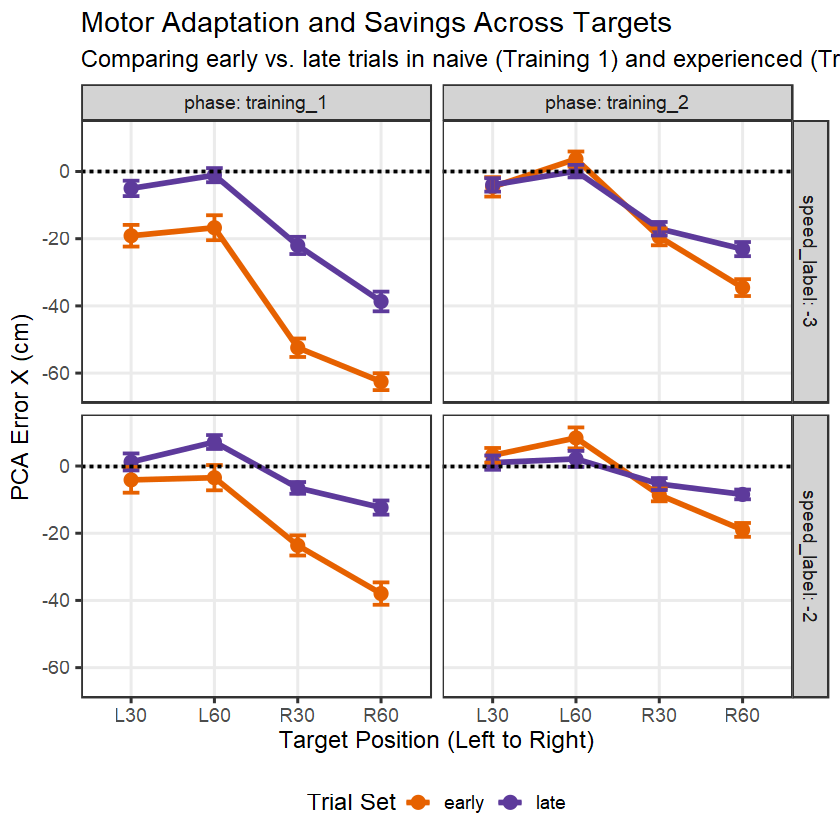

In [79]:
library(afex)
library(emmeans) 

setwd("C:/Users/jacob/water_current_MA/data/spatial_generalization")
dir <- getwd()
print(paste("Working directory:", dir))

df_dual <- read.csv("early_late_phase_PCA_error_projectile_experiment _S1-projectile_experiment_etc_speed_neg3_0_neg2_0.csv")

# Ensure factors
df_dual$ppid_full <- factor(df_dual$ppid_full)
df_dual$speed_label <- factor(df_dual$speed_label)

for (s in speeds_list) {
  
  df_subset <- df_dual[df_dual$speed_label == s,]
  df_subset <- droplevels(df_subset) 
    
  mm_gen <- afex::mixed(PCA_error_X_cm ~ target_x_label * phase * trial_set + (1|ppid_full),
                        data = df_subset, method = "S")
  
  print(afex::nice(mm_gen))
  
  emm_mm_gen <- emmeans(mm_gen, ~ phase)
  emm_by_set <- emmeans(mm_gen, ~ trial_set)
  emm_by_target <- emmeans(mm_gen, ~ phase | target_x_label)
  emm_phase_trial <- emmeans(mm_gen, ~ trial_set | phase)
  emm_3way <- emmeans(mm_gen, ~ trial_set | phase * target_x_label)
  
  print(pairs(emm_mm_gen, infer = TRUE))
  print(pairs(emm_by_target, adjust = "holm", infer = TRUE))
  print(pairs(emm_by_set, adjust = "holm", infer = TRUE))
  print(pairs(emm_3way, adjust = "holm", infer = TRUE))

}

# GENERATE THE PLOTS ---

# Calculate means and standard errors
plot_data <- df_dual %>%
  group_by(speed_label, phase, trial_set, target_x_label) %>%
  summarise(
    mean_error = mean(PCA_error_X_cm, na.rm = TRUE),
    se_error = sd(PCA_error_X_cm, na.rm = TRUE) / sqrt(n()),
    .groups = "drop"
  )

# Create the 3-Way Interaction Plot
adaptation_plot <- ggplot(plot_data, aes(x = target_x_label, y = mean_error, color = trial_set, group = trial_set)) +
  # Draw the lines connecting early to late
  geom_line(linewidth = 1.2) +
  # Add the points with error bars
  geom_point(size = 3) +
  geom_errorbar(aes(ymin = mean_error - se_error, ymax = mean_error + se_error), width = 0.2, linewidth = 0.8) +
  # Create a grid: Speeds on the Y axis, Phases on the X axis
  facet_grid(speed_label ~ phase, labeller = label_both) + 
  # Add the "perfect aim" baseline
  geom_hline(yintercept = 0, linetype = "dashed", color = "black", linewidth = 0.8) +
  # Clean up the theme
  theme_bw(base_size = 14) +
  scale_color_manual(values = c("early" = "#E66100", "late" = "#5D3A9B")) + # Colorblind friendly palette
  labs(
    title = "Motor Adaptation and Savings Across Targets",
    subtitle = "Comparing early vs. late trials in naive (Training 1) and experienced (Training 2) phases",
    x = "Target Position (Left to Right)", 
    y = "PCA Error X (cm)", 
    color = "Trial Set"
  ) +
  theme(
    legend.position = "bottom",
    strip.background = element_rect(fill = "lightgray"),
    panel.grid.minor = element_blank()
  )

# Display the plot
print(adaptation_plot)


In [ ]:
# washout

[1] "Working directory: C:/Users/jacob/water_current_MA/data/spatial_generalization"


Contrasts set to contr.sum for the following variables: target_x_label, phase, strict_id

fixed-effect model matrix is rank deficient so dropping 2 columns / coefficients

Missing cells for: target_x_labelL30:phasewashout_ST, target_x_labelR30:phasewashout_ST.  
Interpret type III hypotheses with care.



Mixed Model Anova Table (Type 3 tests, S-method)

Model: PCA_extent_error_cm_mean_bc ~ target_x_label * phase + (1 | strict_id)
Data: df_subset
                Effect         df         F p.value
1       target_x_label 3, 1934.87 27.44 ***   <.001
2                phase  3, 124.05   4.72 **    .004
3 target_x_label:phase 7, 1561.77   3.32 **    .002
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '+' 0.1 ' ' 1


NOTE: Results may be misleading due to involvement in interactions



 contrast                    estimate   SE  df lower.CL upper.CL t.ratio
 baseline - washout_1_AT        -3.10 1.43 127    -6.49    0.294  -2.166
 baseline - washout_2_AT        -4.45 1.43 127    -7.84   -1.051  -3.105
 baseline - washout_ST         nonEst   NA  NA       NA       NA      NA
 washout_1_AT - washout_2_AT    -1.35 1.52 163    -4.95    2.257  -0.883
 washout_1_AT - washout_ST     nonEst   NA  NA       NA       NA      NA
 washout_2_AT - washout_ST     nonEst   NA  NA       NA       NA      NA
 p.value
  0.0810
  0.0066
      NA
  0.6516
      NA
      NA

Results are averaged over the levels of: target_x_label 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 
Conf-level adjustment: tukey method for comparing a family of 3 estimates 
P value adjustment: tukey method for comparing a family of 3 estimates 
target_x_label = L60:
 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2   -23.82 6.10 67.0    -36

NOTE: Results may be misleading due to involvement in interactions



 target_x_label emmean   SE  df t.ratio p.value
 L30            nonEst   NA  NA      NA      NA
 L60            15.066 1.61 163   9.329  <.0001
 R30            nonEst   NA  NA      NA      NA
 R60            -0.473 1.45 166  -0.326  0.7450

Degrees-of-freedom method: kenward-roger 
P value adjustment: holm method for 2 tests 


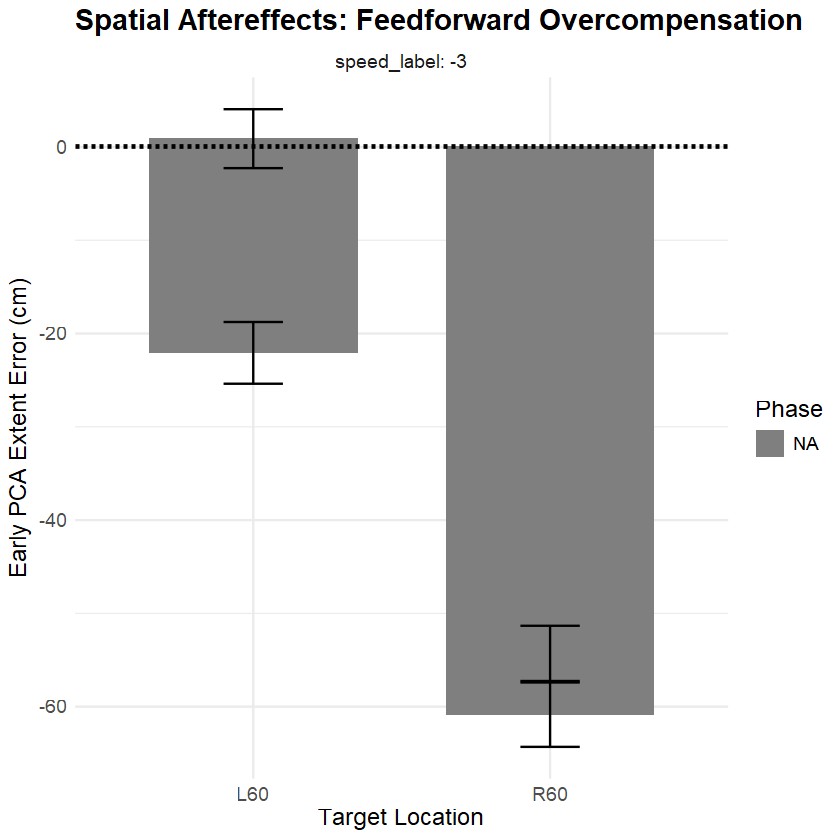

In [17]:
library(afex)
library(emmeans) 

setwd("C:/Users/jacob/water_current_MA/data/spatial_generalization")
dir <- getwd()
print(paste("Working directory:", dir))

df_washout_3 <- read.csv("baseline_washout_novel_TU_3.0M_spatial_generalization_novel_TD_3.0M_spatial_generalization_speed_0_1.csv")

# Ensure factors
df_washout_3$ppid_full <- factor(df_washout_3$ppid_full)
df_washout_3$speed_label <- factor(df_washout_3$speed_label)

for (s in speeds_list) {
  
  df_subset <- df_washout_3[df_washout_3$speed_label == s,]
  df_subset <- droplevels(df_subset) 

  df_subset$strict_id <- paste(df_subset$phase, df_subset$ppid_full, sep="_")
    
  mm_gen <- afex::mixed(PCA_extent_error_cm_mean_bc ~ target_x_label * phase + (1|strict_id),
                        data = df_subset, method = "S")
  print(afex::nice(mm_gen))
    
  emm_mm_gen <- emmeans(mm_gen, ~ phase)
  
  print(pairs(emm_mm_gen, infer = TRUE))
  print(pairs(emm_by_target, adjust = "holm", infer = TRUE))


  emm_by_target <- emmeans(mm_gen, ~ phase | target_x_label)
    
  print(paste("--- Washout vs Baseline by Target for Speed:", s, "---"))
  print(pairs(emm_by_target, adjust = "holm", infer = TRUE))
  
  # 4. THE KILL SHOT: Testing Washout directly against 0
  # This proves that the internal model is actively pushing against nothing
  print(paste("--- Testing Washout Magnitude Against Zero (Feedforward Proof) ---"))
  # Isolate just the washout estimates
  emm_washout_only <- emmeans(mm_gen, ~ target_x_label, at = list(phase = "washout_ST")) 
  print(test(emm_washout_only, null = 0, adjust = "holm"))
}


plot_data <- df_early %>%
  group_by(speed_label, phase, target_x_label) %>%
  summarise(
    mean_error = mean(PCA_extent_error_cm_mean_bc, na.rm = TRUE),
    se_error = sd(PCA_extent_error_cm_mean_bc, na.rm = TRUE) / sqrt(n()),
    .groups = "drop"
  )

# Ensure Washout plots AFTER Baseline for chronological accuracy
plot_data$phase <- factor(plot_data$phase, levels = c("baseline", "washout_ST"))

ggplot(plot_data, aes(x = target_x_label, y = mean_error, fill = phase)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.8), width = 0.7) +
  geom_errorbar(aes(ymin = mean_error - se_error, ymax = mean_error + se_error),
                position = position_dodge(width = 0.8), width = 0.2) +
  facet_wrap(~ speed_label, labeller = label_both) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "black", linewidth = 1) + 
  scale_fill_manual(values = c("baseline" = "#A9A9A9", "washout_ST" = "#D55E00")) + 
  theme_minimal() +
  labs(
    title = "Spatial Aftereffects: Feedforward Overcompensation",
    x = "Target Location",
    y = "Early PCA Extent Error (cm)",
    fill = "Phase"
  ) +
  theme(text = element_text(size = 14),
        plot.title = element_text(face = "bold"))

Contrasts set to contr.sum for the following variables: target_x_label, phase, experiment, ppid_full

fixed-effect model matrix is rank deficient so dropping 6 columns / coefficients

Missing cells for: target_x_labelL30:phasewashout_ST, target_x_labelR30:phasewashout_ST, target_x_labelL30:phasewashout_ST:experimentnovel_TD_3.0M_spatial_generalization, target_x_labelR30:phasewashout_ST:experimentnovel_TD_3.0M_spatial_generalization, target_x_labelR60:phasewashout_ST:experimentnovel_TD_3.0M_spatial_generalization, target_x_labelL60:phasewashout_ST:experimentnovel_TU_3.0M_spatial_generalization, target_x_labelL30:phasewashout_ST:experimentnovel_TU_3.0M_spatial_generalization, target_x_labelR30:phasewashout_ST:experimentnovel_TU_3.0M_spatial_generalization.  
Interpret type III hypotheses with care.



[1] "--- ANOVA Results for Speed: -3 ---"
Mixed Model Anova Table (Type 3 tests, S-method)

Model: PCA_extent_error_cm_mean_bc ~ target_x_label * phase * experiment + 
Model:     (1 | ppid_full)
Data: df_subset
                           Effect         df         F p.value
1                  target_x_label 3, 2481.04  6.91 ***   <.001
2                           phase 3, 2482.24 69.89 ***   <.001
3                      experiment   1, 42.95    4.87 *    .033
4            target_x_label:phase 7, 2481.23  3.67 ***   <.001
5       target_x_label:experiment 3, 2481.02      1.67    .172
6                phase:experiment 2, 2482.66   4.84 **    .008
7 target_x_label:phase:experiment 6, 2481.03   2.92 **    .008
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '+' 0.1 ' ' 1


NOTE: Results may be misleading due to involvement in interactions



[1] "--- Group Comparisons (TD vs TU) ---"
phase = baseline:
 contrast                                                                   
 novel_TD_3.0M_spatial_generalization - novel_TU_3.0M_spatial_generalization
 estimate   SE    df t.ratio p.value
  -0.0203 1.04  97.5  -0.019  0.9845

phase = washout_1_AT:
 contrast                                                                   
 novel_TD_3.0M_spatial_generalization - novel_TU_3.0M_spatial_generalization
 estimate   SE    df t.ratio p.value
  -4.6938 1.35 262.5  -3.483  0.0006

phase = washout_2_AT:
 contrast                                                                   
 novel_TD_3.0M_spatial_generalization - novel_TU_3.0M_spatial_generalization
 estimate   SE    df t.ratio p.value
  -0.9045 1.35 263.1  -0.671  0.5030

phase = washout_ST:
 contrast                                                                   
 novel_TD_3.0M_spatial_generalization - novel_TU_3.0M_spatial_generalization
 estimate   SE    df t.ratio p.val

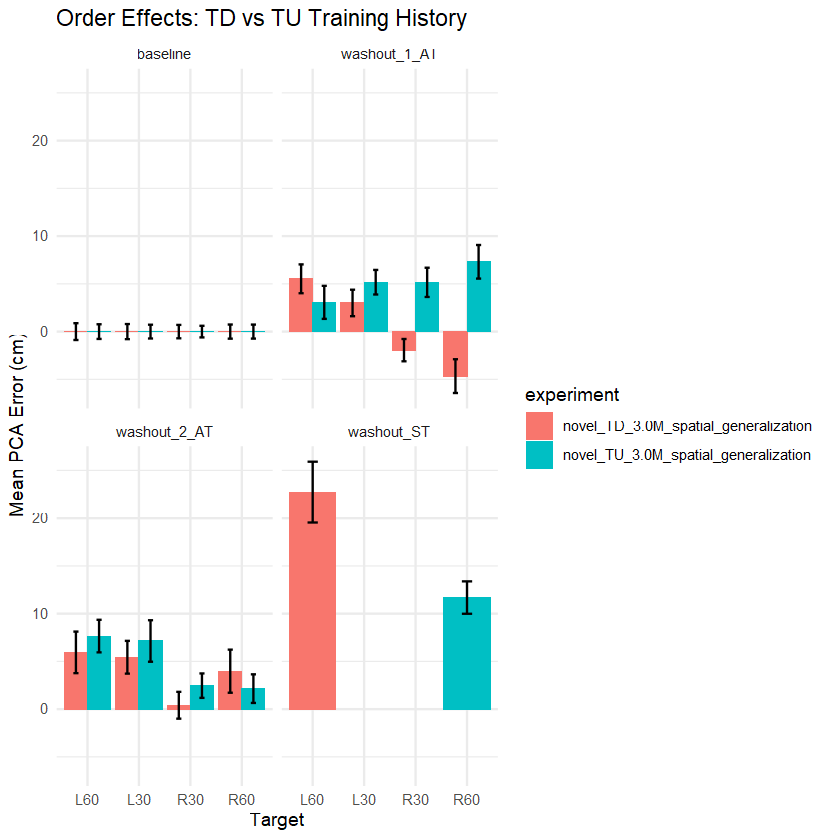

In [7]:

setwd("C:/Users/jacob/water_current_MA/data/spatial_generalization")

df_washout_3 <- read.csv("baseline_washout_novel_TU_3.0M_spatial_generalization_novel_TD_3.0M_spatial_generalization_speed_0.csv")

target_order <- c("L60", "L30", "R30", "R60")
df_washout_3$target_x_label <- factor(df_washout_3$target_x_label, levels = target_order)

# Ensure factors
df_washout_3$ppid_full <- factor(df_washout_3$ppid_full)
df_washout_3$speed_label <- factor(df_washout_3$speed_label)
df_washout_3$experiment <- factor(df_washout_3$experiment) # Order group (TD vs TU)

target_order <- c("L60", "L30", "R30", "R60")
df_washout_3$target_x_label <- factor(df_washout_3$target_x_label, levels = target_order)

# Define the missing list
speeds_list <- unique(df_washout_3$speed_label)

for (s in speeds_list) {
  
  df_subset <- df_washout_3[df_washout_3$speed_label == s,]
  df_subset <- droplevels(df_subset) 

  # REVISED MODEL: Standard Mixed ANOVA structure
  # experiment is Between, target/phase are Within
  mm_order <- afex::mixed(PCA_extent_error_cm_mean_bc ~ target_x_label * phase * experiment + (1|ppid_full),
                        data = df_subset, method = "S")
  
  print(paste("--- ANOVA Results for Speed:", s, "---"))
  print(afex::nice(mm_order))

  # Group Comparisons
  emm_experiment <- emmeans(mm_order, ~ experiment | phase)
  print(paste("--- Group Comparisons (TD vs TU) ---"))
  print(pairs(emm_experiment, adjust = "holm"))
    
  # Target-Specific Comparisons
  emm_target_order <- emmeans(mm_order, ~ experiment | target_x_label * phase)
  print(pairs(emm_target_order, adj = "holm"))
}

# --- CORRECTED PLOTTING ---
# 1. Summarize first to get means and SE for the bars
plot_summary <- df_washout_3 %>%
  group_by(phase, target_x_label, experiment) %>%
  summarise(
    mean_err = mean(PCA_extent_error_cm_mean_bc, na.rm = TRUE),
    se_err = sd(PCA_extent_error_cm_mean_bc, na.rm = TRUE) / sqrt(n()),
    .groups = "drop"
  )

ggplot(plot_summary, aes(x = target_x_label, y = mean_err, fill = experiment)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.9)) +
  geom_errorbar(aes(ymin = mean_err - se_err, ymax = mean_err + se_err), 
                position = position_dodge(width = 0.9), width = 0.2) +
  facet_wrap(~phase) + 
  theme_minimal() +
  labs(title = "Order Effects: TD vs TU Training History",
       y = "Mean PCA Error (cm)", x = "Target")